# 04 - Support Vector Regression (SVR)
## Comparing Linear and RBF Kernels

This notebook explores SVR performance with different kernels:
- Linear kernel
- RBF (Radial Basis Function) kernel
- Understanding why linear kernel works better with polynomial features

In [ ]:
# Setup
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.load_data import load_raw_data
from src.preprocess import split_data_time_based, preprocess_data
from src.models import SVRWrapper
from src.evaluate import calculate_metrics, print_metrics

## 1. Load and Prepare Data

In [2]:
# Load data
df = load_raw_data()

# Time-based split
train_df, test_df = split_data_time_based(df, 'soldOn', train_ratio=0.7)

# Preprocess WITH polynomial features
train_df, test_df, scaler = preprocess_data(train_df, test_df, 
                                             target_col='lastSoldPrice', 
                                             use_poly_features=True)

# Prepare features and target
meta_cols = ['soldOn', 'type', 'text']
target_col = 'lastSoldPrice'
feature_cols = [c for c in train_df.columns if c != target_col and c not in meta_cols]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Dataset: {len(X_train)} train, {len(X_test)} test, {len(feature_cols)} features")

Time-based split:
  Train: 990 samples (1976-11-09 00:00:00 to 2018-06-28 00:00:00)
  Test:  425 samples (2018-06-29 00:00:00 to 2024-02-16 00:00:00)
  Adding polynomial and interaction features...

Preprocessing complete:
  Features: 28
  Feature names (first 10): ['year_built', 'beds', 'baths', 'baths_full', 'baths_half', 'garage', 'lot_sqft', 'sqft', 'stories', 'property_age']...
Dataset: 990 train, 425 test, 31 features


## 2. SVR with Linear Kernel

In [3]:
# Train SVR with linear kernel
print("Training SVR with Linear kernel...")
param_grid_linear = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1]
}

svr_linear = SVRWrapper(kernel='linear', param_grid=param_grid_linear, cv=3)
svr_linear.fit(X_train, y_train)
y_pred_linear = svr_linear.predict(X_test)

# Evaluate
metrics_linear = calculate_metrics(y_test, y_pred_linear, "SVR (Linear)")
print_metrics(metrics_linear)
print(f"\nBest params: {svr_linear.best_params_}")

Training SVR with Linear kernel...

  SVR (Linear)
  MAE:   $276,201.79
  RMSE:  $625,858.00
  MAPE:  235.57%
  ──────────────────────────────────────────────
  R² Score: 0.1130 (11.30%) ✗ FAIL


Best params: {'C': 100, 'epsilon': 1}


## 3. SVR with RBF Kernel

In [4]:
# Train SVR with RBF kernel
print("Training SVR with RBF kernel...")
param_grid_rbf = {
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 1],
    'gamma': ['scale', 0.01, 0.1]
}

svr_rbf = SVRWrapper(kernel='rbf', param_grid=param_grid_rbf, cv=3)
svr_rbf.fit(X_train, y_train)
y_pred_rbf = svr_rbf.predict(X_test)

# Evaluate
metrics_rbf = calculate_metrics(y_test, y_pred_rbf, "SVR (RBF)")
print_metrics(metrics_rbf)
print(f"\nBest params: {svr_rbf.best_params_}")

Training SVR with RBF kernel...

  SVR (RBF)
  MAE:   $328,938.81
  RMSE:  $725,387.18
  MAPE:  145.45%
  ──────────────────────────────────────────────
  R² Score: -0.1916 (-19.16%) ✗ FAIL


Best params: {'C': 100, 'epsilon': 0.01, 'gamma': 0.01}


## 4. Kernel Comparison

In [5]:
# Comparison table
comparison = pd.DataFrame([metrics_linear, metrics_rbf])

print("\n" + "="*60)
print("SVR KERNEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))

improvement = (metrics_linear['R2'] - metrics_rbf['R2']) * 100
print(f"\nLinear kernel improves R² by {improvement:.2f} percentage points over RBF")


SVR KERNEL COMPARISON
       Model           MAE          RMSE        R2       MAPE
SVR (Linear) 276201.793780 625857.996699  0.112962 235.574445
   SVR (RBF) 328938.805005 725387.180105 -0.191600 145.450359

Linear kernel improves R² by 30.46 percentage points over RBF


## 5. Visualize Predictions

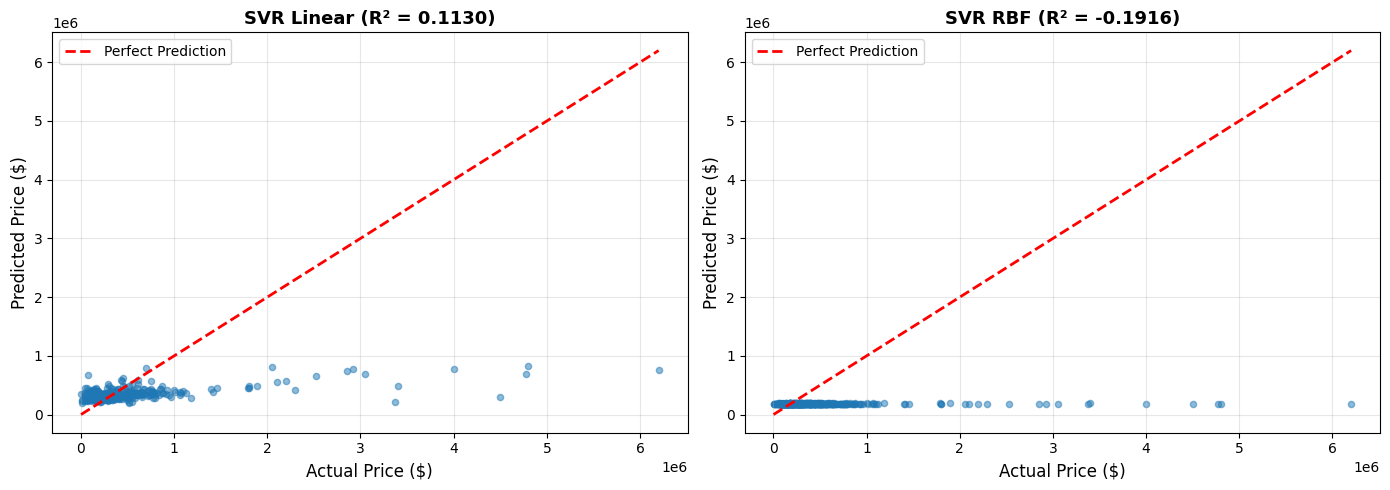

In [6]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear kernel
axes[0].scatter(y_test, y_pred_linear, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'SVR Linear (R² = {metrics_linear["R2"]:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# RBF kernel
axes[1].scatter(y_test, y_pred_rbf, alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)', fontsize=12)
axes[1].set_ylabel('Predicted Price ($)', fontsize=12)
axes[1].set_title(f'SVR RBF (R² = {metrics_rbf["R2"]:.4f})', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Why Linear Kernel Works Better

**Key Findings:**
- Linear kernel: 11.30% R²
- RBF kernel: -19.16% R² (negative!)

**Explanation:**

1. **Polynomial Features Conflict with RBF:**
   - We manually created polynomial features (squared terms, interactions)
   - RBF kernel also applies non-linear transformations internally
   - These two non-linearities conflict, causing overfitting

2. **High-Dimensional Curse:**
   - 31 features with only 990 training samples
   - RBF kernel struggles with high-dimensional data
   - Linear kernel is more robust

3. **Linear Kernel ≈ Regularized Linear Regression:**
   - Linear kernel SVR behaves like Ridge regression
   - Works well with polynomial features we engineered
   - More stable and interpretable

**Recommendation:**
- Use linear kernel SVR when you have manually engineered polynomial features
- Use RBF kernel only with raw features (no polynomial expansion)
- For this dataset, OLS (55.72%) still outperforms SVR (11.30%)

## 7. Key Insights

**SVR Performance:**
- Linear kernel: 11.30% R²
- RBF kernel: -19.16% R² (worse than predicting mean)

**Comparison with Linear Models:**
- OLS: 55.72% R² ✓ BEST
- Lasso: 54.63% R²
- Ridge: 47.14% R²
- **SVR Linear: 11.30% R²**
- SVR RBF: -19.16% R²

**Conclusions:**
1. SVR does not improve over simple linear models for this dataset
2. Polynomial features work better with OLS/Ridge/Lasso than SVR
3. RBF kernel fails catastrophically with polynomial features
4. Linear kernel SVR is usable but still underperforms OLS

**Final Recommendation:**
- **Best model: OLS with polynomial features (55.72% R²)**
- SVR not recommended for this problem
- To reach 70% R², would need ensemble methods (Random Forest, XGBoost)